In [2]:
import sys
import os
import gc
import warnings
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from scipy.stats import norm
from scipy.optimize import brentq

# Add local modules
sys.path.append('.')
import BTSSlayers as btss

# Suppress warnings
warnings.filterwarnings("ignore")

In [3]:
def find_intersection(mean1, std1, mean2, std2):
    """Find intersection between two Gaussian PDFs."""
    func = lambda x: norm.pdf(x, mean1, std1) - norm.pdf(x, mean2, std2)
    a = min(mean1 - 3 * std1, mean2 - 3 * std2)
    b = max(mean1 + 3 * std1, mean2 + 3 * std2)
    
    if func(a) * func(b) > 0:
        return (mean1 + mean2) / 2
    try:
        return brentq(func, a, b)
    except ValueError:
        return (mean1 + mean2) / 2

def get_gmm_thresholds_iki(log_iki_series):
    """
    Fits 3-component GMM to LogIKI data and returns thresholds.
    Returns dictionary with gmm_iki_auto and gmm_iki_cons.
    """
    X = log_iki_series.dropna().values.reshape(-1, 1)
    # Default NaNs
    res = {'GMM_Threshold_LogIKI': np.nan, 'gmm_iki_auto': np.nan, 'gmm_iki_cons': np.nan}
    
    # Needs enough data points
    if len(X) < 5: 
        return res

    try:
        # --- 2 Component  ---
        gmm2 = GaussianMixture(n_components=2, random_state=42)
        gmm2.fit(X)
        means2 = gmm2.means_.flatten()
        stds2 = np.sqrt(gmm2.covariances_.flatten())
        order2 = np.argsort(means2)
        res['GMM_Threshold_LogIKI'] = find_intersection(means2[order2[0]], stds2[order2[0]], 
                                                        means2[order2[1]], stds2[order2[1]])

        # --- 3 Component ---
        gmm3 = GaussianMixture(n_components=3, random_state=42)
        gmm3.fit(X)
        means = gmm3.means_.flatten()
        stds = np.sqrt(gmm3.covariances_.flatten())
        order = np.argsort(means)
        
        # Automatic Threshold: Intersection of Comp 0 & 1 (Fastest & Middle)
        res['gmm_iki_auto'] = find_intersection(means[order[0]], stds[order[0]], 
                                                means[order[1]], stds[order[1]])
        # Conscious Threshold: Intersection of Comp 1 & 2 (Middle & Slowest)
        res['gmm_iki_cons'] = find_intersection(means[order[1]], stds[order[1]], 
                                                means[order[2]], stds[order[2]])
    except Exception:
        pass
        
    return res

In [64]:
def process_single_session(session_name, tables):
    """
    Computes all metrics for a SINGLE session data dictionary.
    """
    results = {'StudySession': session_name}
    
    au = tables.get('au1')
    kd = tables.get('kd')
    tt = tables.get('tt')
    
    if au is None or kd is None or tt is None or kd.empty:
        return None

    # --- 1. AU Metrics (LogPUB, LogKBI) ---
    if not au.empty and 'PUB' in au.columns and 'KBI' in au.columns:
        
        # from the PERL implementation
        pub_val = au['PUB'].iloc[0] 
        kbi_val = au['KBI'].iloc[0]

        # this is actually a variant of Munoz method: call this KBI1 / PUB1 
        results['PUB1'] = pub_val if pub_val > 0 else np.nan
        results['KBI1'] = kbi_val if kbi_val > 0 else np.nan
        
        # keep multiplication factor to compare with the other thresholds
        results['LogPUB1'] = np.log(pub_val) if pub_val > 0 else np.nan
        results['LogKBI1'] = np.log(kbi_val) if kbi_val > 0 else np.nan
#        results['LogPUB'] = np.log(pub_val / 3) if pub_val > 0 else np.nan
#        results['LogKBI'] = np.log(kbi_val / 2) if kbi_val > 0 else np.nan
    else:
        results['LogPUB1'] = np.nan
        results['LogKBI1'] = np.nan

    # --- 2. Calculate Standard IKI (NextPause - NextDur) ---
    kd['NextChar'] = kd['Char'].shift(-1).fillna('_')
    kd['BI'] = (kd['Char'] + kd['NextChar']).astype(str)
    
    kd['NextType'] = kd['Type'].shift(-1).fillna(kd['Type'])
    kd['NextPause'] = kd['Pause'].shift(-1).fillna(kd['Pause'])
    kd['NextDur'] = kd['Dur'].shift(-1).fillna(kd['Dur'])
    kd['IKI'] = kd['NextPause'] - kd['NextDur']
    
    # Border Logic
    conditions = [
        kd['BI'].str.match(r"__"),     # SS
        kd['BI'].str.match(r"_[^_]"),  # SW
        kd['BI'].str.match(r"[^_]_"),  # WS
        kd['BI'].str.match(r"[^_][^_]")# WW
    ]
    choices = ['SS', 'SW', 'WS', 'WW']
    kd['Border'] = np.select(conditions, choices, default='XX')

    # --- 3. Compute Stats ---
    lang = kd['TL'].iloc[0] if 'TL' in kd.columns else 'en'
    chunk_length = 1.5 if lang in ['zh', 'ja'] else 3

    valid_mask = (kd['Type'] == 'Mins') & (kd['NextType'] == 'Mins')
    valid_rows = kd[valid_mask]

    if lang in ['zh', 'ja']:
        if not valid_rows.empty:
            dur_per_stroke = valid_rows['Dur'] / valid_rows['Strokes']
            counts = valid_rows['Strokes'].values
            WW = np.repeat(dur_per_stroke.values, counts.astype(int)) 
            BW = valid_rows['IKI'].values
            SW = valid_rows['IKI'].values
            WS = valid_rows['IKI'].values
    else:
        WW = valid_rows.loc[valid_rows['Border'] == 'WW', 'IKI'].values
        SW = valid_rows.loc[valid_rows['Border'] == 'SW', 'IKI'].values
        WS = valid_rows.loc[valid_rows['Border'] == 'WS', 'IKI'].values
        BW = valid_rows.loc[(valid_rows['Border'] == 'SW') | (valid_rows['Border'] == 'WS') , 'IKI'].values #+ valid_rows.loc[valid_rows['Border'] == 'WS', 'IKI'].values
        
    # Word Length (wl) calculation from TT
    chars_count = tt['TToken'].str.len().sum()
    words_count = len(tt)
    wl = chars_count / words_count if words_count > 0 else 1

    # Medians
    median_ww = np.median(WW) if len(WW) > 0 else 0
    median_bw = np.median(BW) if len(BW) > 0 else 0
    median_sw = np.median(SW) if len(WS) > 0 else 0
    median_ws = np.median(WS) if len(WS) > 0 else 0

    results['WW'] = median_ww
    results['BW'] = median_bw
    results['SW'] = median_sw
    results['WS'] = median_ws

    
    # Aachen Micro-Unit Delimiter 
    std_ww = np.std(WW) if len(WW) > 0 else 0
    results['MUD'] = int(median_ww) + 2*std_ww
    results['LogMUD'] =  np.log(results['MUD'])
    
    # Munoz sespites: RSP / Task-segment Pauses: TSP
    results['RSP'] = 2 * int(median_ww)
    results['TSP'] = 3 * int(median_sw)
    results['LogTSP'] = np.log(results['TSP'])

    # PUB2 (Quantile based on average word length and word cluster size)
    q_target = max(0.0, min(1.0, 1 - (1 / (wl * chunk_length))))
    results['PUB'] = int(np.quantile(kd['IKI'].dropna(), q_target)) if not kd['IKI'].dropna().empty else 0
    results['LogPUB'] = np.log(results['PUB'])


    # quantile of threshold measures
    results['Q_PUB1'] = np.mean(kd['IKI'] < results['PUB1'])
    results['Q_KBI'] = np.mean(kd['IKI'] < results['KBI1'])
    results['Q_MUD'] = np.mean(kd['IKI'] < results['MUD'])
    results['Q_PUB'] = np.mean(kd['IKI'] < results['PUB'])
    results['Q_TSP'] = np.mean(kd['IKI'] < results['TSP'])
    results['Q_RSP'] = np.mean(kd['IKI'] < results['RSP'])
            
    
    # --- 4. LogIKI Calculation (Based on Time Diff) ---
    kd = kd.sort_values('Time')
    kd['IKI_TimeDiff'] = kd['Time'].diff()
    
    # Filter valid positive values for Log calculation
    valid_time_diffs = kd['IKI_TimeDiff'][kd['IKI_TimeDiff'] > 0].dropna()
    log_iki = np.log(valid_time_diffs)
    
    # Quantile_iki: Explicitly 75th percentile of LogIKI
#    results['LogQ75'] = np.quantile(log_iki, 0.75) if not log_iki.empty else np.nan
    
    # Quantile_iki: Explicitly 75th percentile of LogIKI
    results['Q75'] = np.quantile(kd['IKI'], 0.75) 
    results['LogQ75'] = np.log(results['Q75'])

    # --- 5. GMM Analysis (LogIKI) ---
    gmm_res = get_gmm_thresholds_iki(log_iki)
    results.update(gmm_res)

    return results

In [65]:
print("Reading session list...")
GD = pd.read_csv('sorted.gaze.clean.txt', sep="\t", dtype=None)
session_list = GD['Study-Session'].unique()

all_session_data = []

print(f"Processing {len(session_list)} sessions sequentially...")

L = {}

for i, session in enumerate(session_list):
    if i % 10 == 0:
        print(f"  Processed {i}/{len(session_list)} sessions... (Memory Cleanup)")
        gc.collect()
    try:
        # Read only specific session
        tables = btss.readBTSSsessions([session], layers=['au1', 'fd', 'kd', 'tt'], verbose=0)
        
        row_metrics = process_single_session(session, tables)
        
        kd = tables.get('kd')
        sl = kd['SL'].iloc[0] if 'SL' in kd.columns else 'en'
        tl = kd['TL'].iloc[0] if 'TL' in kd.columns else 'en'

        lng = f"{sl}-{tl}"
        L.setdefault(lng, 0)
        L[lng] += 1
        
        if row_metrics:
            all_session_data.append(row_metrics)
            
        del tables
        
    except Exception as e:
        print(f"  Error processing session {session}: {e}")
        continue

Reading session list...
Processing 490 sessions sequentially...
  Processed 0/490 sessions... (Memory Cleanup)
  Processed 10/490 sessions... (Memory Cleanup)
  Processed 20/490 sessions... (Memory Cleanup)
  Processed 30/490 sessions... (Memory Cleanup)
  Processed 40/490 sessions... (Memory Cleanup)
  Processed 50/490 sessions... (Memory Cleanup)
  Processed 60/490 sessions... (Memory Cleanup)
  Processed 70/490 sessions... (Memory Cleanup)
  Processed 80/490 sessions... (Memory Cleanup)
  Processed 90/490 sessions... (Memory Cleanup)
  Processed 100/490 sessions... (Memory Cleanup)
  Processed 110/490 sessions... (Memory Cleanup)
  Processed 120/490 sessions... (Memory Cleanup)
  Processed 130/490 sessions... (Memory Cleanup)
  Processed 140/490 sessions... (Memory Cleanup)
  Processed 150/490 sessions... (Memory Cleanup)
  Processed 160/490 sessions... (Memory Cleanup)
  Processed 170/490 sessions... (Memory Cleanup)
  Processed 180/490 sessions... (Memory Cleanup)
  Processed 190/

In [66]:
print("Creating final DataFrame...")
final_df = pd.DataFrame(all_session_data)

#final_df['GMM'] = 3 * final_df.gmm_iki_cons

          
rename = {'GMM_Threshold_LogIKI' : '2GMM',
          'gmm_iki_auto' : '3Ga',
          'gmm_iki_cons' : '3Gr'
         }
          
final_metrics = final_df.rename(columns=rename)


X = '''
StudySession', 'PUB', 'KBI', 'LogPUB', 'LogKBI', 'BW', 'SW', 'WS',
       'Aachen', 'LogAachen', 'RSP', 'TSP', 'LogTSP', 'CHK', 'LogCHK',
       'QBW_PUB', 'QBW_KBI', 'QBW_Aachen', 'QBW_CHK', 'QBW_TSP', 'QWW_RSP',
       'Q75', 'GMM_Threshold_LogIKI', 'gmm_iki_auto', 'gmm_iki_cons'

cols_to_save = [
    #"StudySession", 
    'BW', 'BW1', 'BW2',
    "KBI","PUB","A","AW", "B", "M", 
    "LogKBI", "LogPUB", "LogA","LogAW","LogB","LogM",
    "Q75", #"QWW2", "QBW0", "QBW1", "QBW2","QBW3", 
    "GMM_Threshold_LogIKI", "gmm_iki_auto", "gmm_iki_cons", 
]

for c in cols_to_save:
    if c not in final_df.columns:
        final_df[c] = np.nan

final_metrics = final_df[cols_to_save]
'''


Creating final DataFrame...


In [63]:
#print(final_metrics.head(5))
#print(FM.head(5))
final_df.columns
final_metrics.columns

Index(['StudySession', 'PUB1', 'KBI1', 'LogPUB1', 'LogKBI1', 'BW', 'SW', 'WS',
       'MUD', 'LogMUD', 'RSP', 'TSP', 'LogTSP', 'PUB', 'LogPUB', 'Q_PUB1',
       'Q_KBI', 'Q_MUD', 'Q_PUB', 'Q_TSP', 'Q_RSP', 'Q_75', '2GMM', '3Ga',
       '3Gr', 'GMM'],
      dtype='object')

In [68]:
allCols = ['SW', 'WW', 'RSP',
           'MUD', 'TSP', 'PUB', #'LogTSP', 
           'LogMUD',  'LogTSP', 'LogPUB', 
           'Q_PUB', 'Q_KBI', 'Q_MUD', 'Q_TSP', 'Q_RSP', 
           'Q75',
           '3Ga', '3Gr', '2GMM', 
          ]
final_metrics[allCols].corr()

,SW,WW,RSP,MUD,TSP,PUB,LogMUD,LogTSP,LogPUB,Q_PUB,Q_KBI,Q_MUD,Q_TSP,Q_RSP,Q75,3Ga,3Gr,2GMM
SW,1.000000,0.853550,0.853557,0.440511,1.000000,0.721088,0.444314,0.887292,0.625879,-0.155615,-0.225854,-0.003730,0.414637,-0.190215,0.900475,-0.091443,0.475222,-0.110045
WW,0.853550,1.000000,1.000000,0.441782,0.853560,0.625887,0.445836,0.729871,0.531542,-0.186502,0.052104,0.069367,0.283517,0.113568,0.927084,-0.102415,0.453559,-0.148265
RSP,0.853557,1.000000,1.000000,0.441805,0.853567,0.625916,0.445880,0.729909,0.531600,-0.186493,0.052045,0.069368,0.283503,0.113526,0.927088,-0.102419,0.453584,-0.148206
MUD,0.440511,0.441782,0.441805,1.000000,0.440524,0.508691,0.882483,0.448363,0.511305,-0.016939,-0.124428,0.479940,0.012655,-0.094964,0.467853,-0.020581,0.360604,0.018125
TSP,1.000000,0.853560,0.853567,0.440524,1.000000,0.721101,0.444329,0.887274,0.625886,-0.155583,-0.225822,-0.003697,0.414617,-0.190189,0.900474,-0.091451,0.475223,-0.110062
PUB,0.721088,0.625887,0.625916,0.508691,0.721101,1.000000,0.550083,0.686285,0.931054,0.045741,-0.332274,-0.054162,-0.090544,-0.261538,0.713951,0.008453,0.583013,0.053070
LogMUD,0.444314,0.445836,0.445880,0.882483,0.444329,0.550083,1.000000,0.514843,0.626122,0.000291,-0.209960,0.588991,-0.045415,-0.172280,0.486698,-0.022178,0.475239,0.087697
LogTSP,0.887292,0.729871,0.729909,0.448363,0.887274,0.686285,0.514843,1.000000,0.709400,-0.164536,-0.364477,0.005391,0.476144,-0.327387,0.814728,-0.060372,0.560436,0.005819
LogPUB,0.625879,0.531542,0.531600,0.511305,0.625886,0.931054,0.626122,0.709400,1.000000,0.075691,-0.410935,-0.012327,-0.148278,-0.344888,0.628848,0.016830,0.649138,0.145141
Q_PUB,-0.155615,-0.186502,-0.186493,-0.016939,-0.155583,0.045741,0.000291,-0.164536,0.075691,1.000000,0.430118,0.476968,0.097391,0.390561,-0.300600,-0.000894,-0.211371,-0.046901


## WW, SW, WS Correlation 
A weak correlation with similar distributions happens when variables change together but not consistently (scattered points but similar overall shape), often due to a lurking variable (like temperature affecting both ice cream sales and sunburns) or non-linear patterns (curved relationships that correlation misses). Conversely, similar distributions with a strong correlation (even weak overall) can occur if data is split into subgroups with opposite trends (e.g., one group increasing, another decreasing) causing them to cancel out when combined, creating a deceptive weak overall correlation despite clear patterns within subgroups

          WW        SW        WS
WW  1.000000  0.853550  0.698604
SW  0.853550  1.000000  0.560731
WS  0.698604  0.560731  1.000000


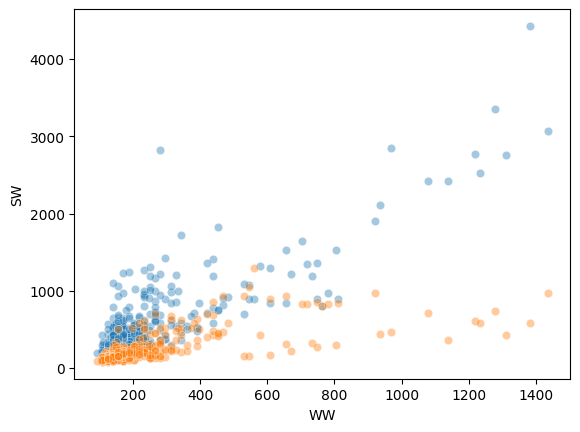

<Axes: xlabel='SW', ylabel='WS'>

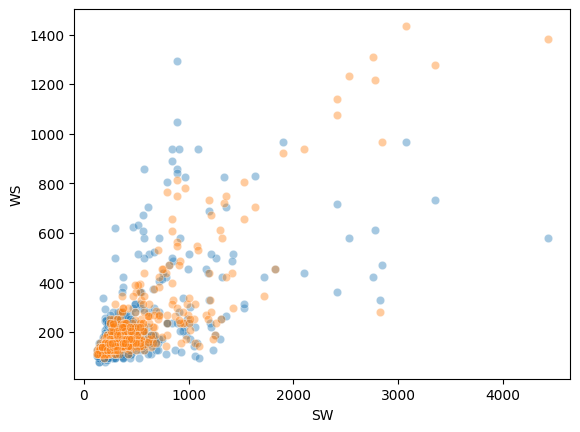

In [87]:
cols = ['WW', 'SW', 'WS']

print(final_metrics[cols].corr())

sns.scatterplot(data=final_metrics, x='WW', y='SW', alpha=0.4)
sns.scatterplot(data=final_metrics, x='WW', y='WS', alpha=0.4)
plt.show()
sns.scatterplot(data=final_metrics, x='SW', y='WS', alpha=0.4)
sns.scatterplot(data=final_metrics, x='SW', y='WW', alpha=0.4)


## Correlation RSP', 'TSP', 'MUD', 'PUB'

Identical Correlation  RSP', 'TSP' as 'WW', 'SW',


          RSP       TSP       MUD       PUB
RSP  1.000000  0.853567  0.441805  0.625916
TSP  0.853567  1.000000  0.440524  0.721101
MUD  0.441805  0.440524  1.000000  0.508691
PUB  0.625916  0.721101  0.508691  1.000000


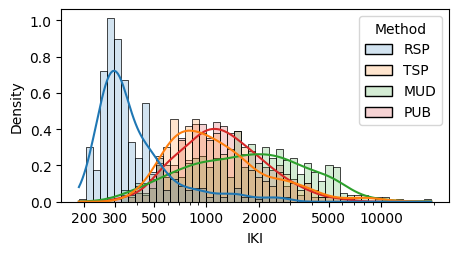

In [80]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mpl_ticker
import seaborn as sns

cols = ['RSP', 'TSP', 'MUD', 'PUB']

print(final_metrics[cols].corr())

f, ax = plt.subplots(figsize=(5, 2.5))

FM_long = pd.melt(final_metrics, 
                  value_vars=cols, 
                  var_name='Method', 
                  value_name='IKI')

sns.histplot(data=FM_long, x='IKI', log_scale=True, bins=50, kde=True, stat='density', hue="Method", alpha=0.2, ax=ax)

custom_ticks = [200, 300, 500,1000, 2000, 5000, 10000]
ax.set_xticks(custom_ticks)
ax.xaxis.set_major_formatter(mpl_ticker.ScalarFormatter()) 


## Quantiles

<Axes: xlabel='Quantiles', ylabel='Density'>

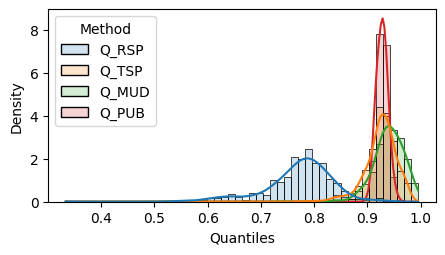

In [57]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mpl_ticker
import seaborn as sns


# 3. Plotting
f, ax = plt.subplots(figsize=(5, 2.5))

vars=['Q_RSP', 'Q_TSP', 'Q_MUD','Q_PUB']
FM_long = pd.melt(final_metrics, 
                  value_vars = vars, 
                  var_name='Method', 
                  value_name='Quantiles')

sns.histplot(data=FM_long, x='Quantiles', bins=50, kde=True, stat='density', hue="Method", alpha=0.2, ax=ax)

#custom_ticks = [200, 300, 500, 700, 1000, 2000, 5000, 10000]
#ax.set_xticks(custom_ticks)
#ax.xaxis.set_major_formatter(mpl_ticker.ScalarFormatter()) 


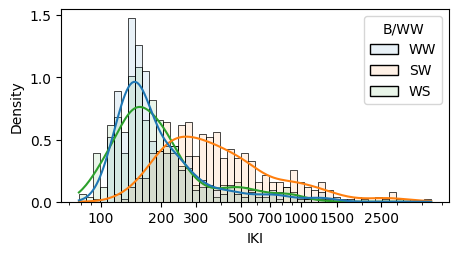

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

f, ax = plt.subplots(figsize=(5, 2.5))

FM_long = pd.melt(final_metrics, 
                  value_vars=['WW', 'SW', 'WS'], 
                  var_name='B/WW', 
                  value_name='IKI')

sns.histplot(data=FM_long, x='IKI', log_scale=True, bins=50, kde=True, stat='density', hue="B/WW", alpha=0.1, ax=ax)
custom_ticks = [100, 200, 300, 500, 700, 1000, 1500, 2500]
ax.set_xticks(custom_ticks)
ax.xaxis.set_major_formatter(mpl_ticker.ScalarFormatter()) 


## log 

<Axes: xlabel='value', ylabel='Density'>

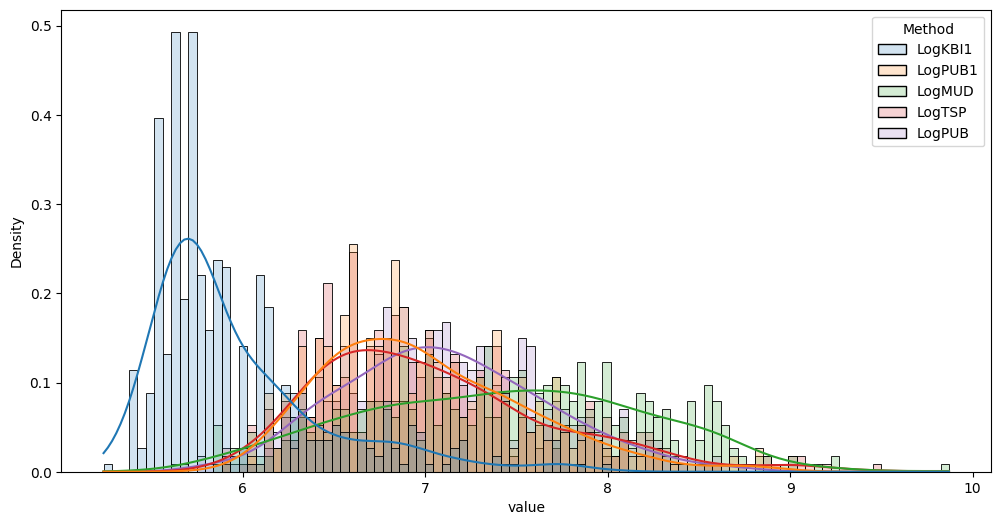

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
# 3. Plotting
plt.figure(figsize=(12, 6))

FM_long = pd.melt(final_metrics, 
                  value_vars=['LogKBI1', 'LogPUB1', 'LogMUD', 'LogTSP', 'LogPUB'], 
                  var_name='Method', 
                  value_name='value')

sns.histplot(data=FM_long, x='value',  bins=100, kde=True, stat='density', hue="Method", alpha=0.2)
